In [1]:
import os
print(os.getcwd())
os.chdir('C:/Users/Eva/Downloads/BRUR_2026(STAT-2205)/R_PROGRAMMING')
os.listdir()

C:\Users\Eva


['.RData',
 '.RDataTmp',
 '.Rhistory',
 'airline_passenger.csv',
 'airline_passenger.sav',
 'askpass',
 'assignment.R',
 'backports',
 'base64enc',
 'binary.csv',
 'binary.xlsx',
 'bit',
 'bit64',
 'blob',
 'broom',
 'BSDA',
 'bslib',
 'cachem',
 'callr',
 'cellranger',
 'cli',
 'clipr',
 'conflicted',
 'corrplot',
 'cpp11',
 'crayon',
 'CSV_FILE_PROBLEM.R',
 'curl',
 'data.table',
 'DBI',
 'dbplyr',
 'digest',
 'dplyr',
 'dtplyr',
 'e1071',
 'evaluate',
 'farver',
 'fastmap',
 'file4340575ae6c',
 'flight_data.csv',
 'flight_data_1.csv',
 'flight_data_2.csv',
 'flight_data_3.csv',
 'flight_data_3.xlsx',
 'fontawesome',
 'forcats',
 'fs',
 'gargle',
 'generics',
 'ggplot2',
 'glue',
 'googledrive',
 'googlesheets4',
 'gtable',
 'haven',
 'highr',
 'hms',
 'htmltools',
 'httr',
 'hw.R',
 'ids',
 'isoband',
 'jquerylib',
 'jsonlite',
 'knitr',
 'labeling',
 'lifecycle',
 'lubridate',
 'lung_disease.csv',
 'lung_disease.xlsx',
 'magrittr',
 'memoise',
 'mime',
 'modelr',
 'openssl',
 'pill

In [2]:
import pandas as pd
import numpy as np

# Load data and take random sample
df = pd.read_csv('flight_data.csv')
np.random.seed(10063)                    # Your ID last 5 digits
sample_df = df.sample(n=10063, random_state=10063).copy()

# Q1 Analysis
print(sample_df['coach_price'].describe())

count    10063.000000
mean       377.725740
std         67.229885
min        130.500000
25%        332.377500
50%        381.540000
75%        427.965000
max        562.925000
Name: coach_price, dtype: float64


In [3]:
import pandas as pd
import numpy as np

# Load data and sample
df = pd.read_csv('flight_data.csv')
np.random.seed(10063)
sample_df = df.sample(n=10063, random_state=10063).copy()

# Q2 Analysis
eight_hr = sample_df[sample_df['hours'] == 8]
print("Number of 8-hour flights:", len(eight_hr))
print(eight_hr['coach_price'].describe())

Number of 8-hour flights: 211
count    211.000000
mean     426.952299
std       57.840730
min      235.745000
25%      393.770000
50%      426.505000
75%      467.630000
max      562.925000
Name: coach_price, dtype: float64


In [5]:
import pandas as pd
import numpy as np

# Load data and sample
df = pd.read_csv('flight_data.csv')
np.random.seed(10063)
sample_df = df.sample(n=10063, random_state=10063).copy()

# Q3 Analysis
print("=== Flight Delay Distribution ===")
print(sample_df['delay'].describe())

print("\nSignificant Delays:")
print("Delays > 30 minutes:", (sample_df['delay'] > 30).sum(), 
      f"({round((sample_df['delay'] > 30).mean()*100, 2)}%)")
print("Delays > 60 minutes:", (sample_df['delay'] > 60).sum())

print("\nMost Common Delays:")
print(sample_df['delay'].value_counts().head(10))

=== Flight Delay Distribution ===
count    10063.000000
mean        13.056643
std         40.118008
min          0.000000
25%          9.000000
50%         10.000000
75%         13.000000
max       1560.000000
Name: delay, dtype: float64

Significant Delays:
Delays > 30 minutes: 502 (4.99%)
Delays > 60 minutes: 7

Most Common Delays:
delay
10    1443
9     1303
11    1290
12     968
8      915
0      811
13     538
7      502
14     238
6      190
Name: count, dtype: int64


In [6]:
import pandas as pd
import numpy as np

# Load data and sample
df = pd.read_csv('flight_data.csv')
np.random.seed(10063)
sample_df = df.sample(n=10063, random_state=10063).copy()

# Q4 Analysis
numeric_cols = ['miles', 'passengers', 'delay', 'hours', 'coach_price']
correlation = sample_df[numeric_cols].corr()['coach_price'].round(4)
print(correlation)

miles          0.3408
passengers     0.1667
delay          0.0129
hours          0.3344
coach_price    1.0000
Name: coach_price, dtype: float64


In [7]:
import pandas as pd
import numpy as np

# Load data and sample
df = pd.read_csv('flight_data.csv')
np.random.seed(10063)
sample_df = df.sample(n=10063, random_state=10063).copy()

# Q5 Analysis
correlation = sample_df['coach_price'].corr(sample_df['firstclass_price'])
print(f"Correlation between Coach and First Class Price: {correlation:.4f}")

# Additional insights
print("\nSummary Statistics:")
print("Coach Price Mean    :", round(sample_df['coach_price'].mean(), 2))
print("First Class Price Mean:", round(sample_df['firstclass_price'].mean(), 2))

Correlation between Coach and First Class Price: 0.7547

Summary Statistics:
Coach Price Mean    : 377.73
First Class Price Mean: 1457.39


In [8]:
import pandas as pd
import numpy as np

# Load data and sample
df = pd.read_csv('flight_data.csv')
np.random.seed(10063)
sample_df = df.sample(n=10063, random_state=10063).copy()

# Q6 Analysis
features = ['inflight_meal', 'inflight_entertainment', 'inflight_wifi']

for feature in features:
    print(f"\n=== {feature.replace('_', ' ').title()} ===")
    stats = sample_df.groupby(feature)['coach_price'].agg(['count', 'mean', 'median']).round(2)
    print(stats)
    premium = stats.loc['Yes', 'mean'] - stats.loc['No', 'mean']
    print(f"Price Premium (Yes vs No): ${premium:.2f}")


=== Inflight Meal ===
               count    mean  median
inflight_meal                       
No              7083  372.15  375.23
Yes             2980  390.98  397.56
Price Premium (Yes vs No): $18.83

=== Inflight Entertainment ===
                        count    mean  median
inflight_entertainment                       
No                       1954  320.49  325.03
Yes                      8109  391.52  396.66
Price Premium (Yes vs No): $71.03

=== Inflight Wifi ===
               count    mean  median
inflight_wifi                       
No               966  315.14  317.84
Yes             9097  384.37  388.53
Price Premium (Yes vs No): $69.23


In [9]:
import pandas as pd
import numpy as np

# Load data and sample
df = pd.read_csv('flight_data.csv')
np.random.seed(10063)
sample_df = df.sample(n=10063, random_state=10063).copy()

# Q7 Analysis
print("Overall Average Passengers:", round(sample_df['passengers'].mean(), 2))
print("\nAverage Passengers by Flight Duration (hours):")
print(sample_df.groupby('hours')['passengers'].mean().round(2))

Overall Average Passengers: 207.81

Average Passengers by Flight Duration (hours):
hours
1    208.06
2    208.20
3    207.32
4    207.89
5    208.03
6    206.88
7    208.31
8    205.73
Name: passengers, dtype: float64


In [10]:
import pandas as pd
import numpy as np

# Load data and sample
df = pd.read_csv('flight_data.csv')
np.random.seed(10063)
sample_df = df.sample(n=10063, random_state=10063).copy()

# Q8 Analysis
print("=== Coach Price: Weekend vs Weekday ===")
print("Weekend Coach Mean    :", round(sample_df[sample_df['weekend']=='Yes']['coach_price'].mean(), 2))
print("Weekday Coach Mean    :", round(sample_df[sample_df['weekend']=='No']['coach_price'].mean(), 2))

print("\n=== First Class Price: Weekend vs Weekday ===")
print("Weekend First Class Mean:", round(sample_df[sample_df['weekend']=='Yes']['firstclass_price'].mean(), 2))
print("Weekday First Class Mean:", round(sample_df[sample_df['weekend']=='No']['firstclass_price'].mean(), 2))

=== Coach Price: Weekend vs Weekday ===
Weekend Coach Mean    : 406.54
Weekday Coach Mean    : 322.32

=== First Class Price: Weekend vs Weekday ===
Weekend First Class Mean: 1560.99
Weekday First Class Mean: 1258.17


In [11]:
import pandas as pd
import numpy as np

# Load data and sample
df = pd.read_csv('flight_data.csv')
np.random.seed(10063)
sample_df = df.sample(n=10063, random_state=10063).copy()

# Q9 Analysis
print("=== Coach Price: Redeye vs Non-Redeye by Day of Week ===")
print(sample_df.groupby(['day_of_week', 'redeye'])['coach_price'].mean().unstack().round(2))

=== Coach Price: Redeye vs Non-Redeye by Day of Week ===
redeye           No     Yes
day_of_week                
Friday       404.77  339.91
Monday       323.82  260.40
Saturday     417.26  350.83
Sunday       404.89  347.86
Thursday     327.00  262.41
Tuesday      325.57  273.16
Wednesday    324.82  262.56


In [49]:
import pandas as pd
import numpy as np

# Load data and take sample
df = pd.read_csv('flight_data.csv')
np.random.seed(10063)
sample_df = df.sample(n=10063, random_state=10063).copy()

# Key numeric variables
numeric_vars = ['miles', 'passengers', 'delay', 'hours', 
                'coach_price', 'firstclass_price']

print("=== SUMMARY STATISTICS ===\n")
summary = sample_df[numeric_vars].describe().round(2)
print(summary)

# Extra: Standard Deviation separately
print("\n=== Standard Deviation ===")
print(sample_df[numeric_vars].std().round(2))

=== SUMMARY STATISTICS ===

          miles  passengers     delay     hours  coach_price  firstclass_price
count  10063.00    10063.00  10063.00  10063.00     10063.00          10063.00
mean    2011.22      207.81     13.06      3.64       377.73           1457.39
std      944.61       12.89     40.12      1.74        67.23            162.55
min      104.00      139.00      0.00      1.00       130.50           1020.21
25%     1342.00      204.00      9.00      2.00       332.38           1303.79
50%     1981.00      210.00     10.00      4.00       381.54           1506.87
75%     2474.00      215.00     13.00      4.00       427.96           1583.95
max     4545.00      239.00   1560.00      8.00       562.92           1846.14

=== Standard Deviation ===
miles               944.61
passengers           12.89
delay                40.12
hours                 1.74
coach_price          67.23
firstclass_price    162.55
dtype: float64


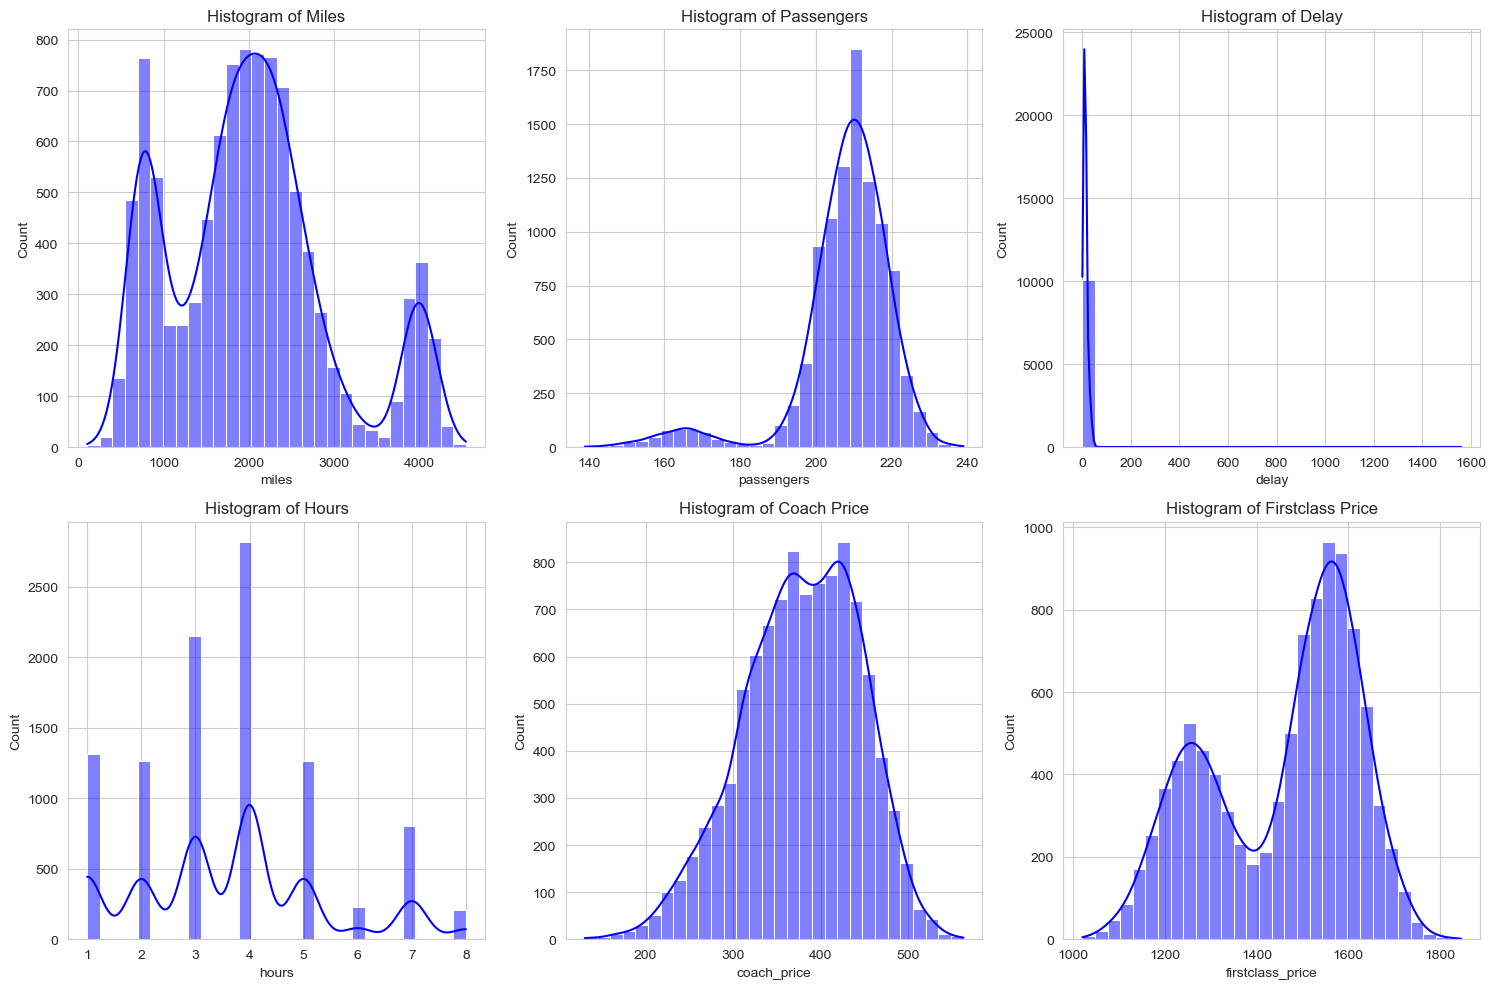

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data and sample
df = pd.read_csv('flight_data.csv')
np.random.seed(10063)
sample_df = df.sample(n=10063, random_state=10063).copy()

# Set style
sns.set_style("whitegrid")

# Create multiple histograms
numeric_cols = ['miles', 'passengers', 'delay', 'hours', 'coach_price', 'firstclass_price']

plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(sample_df[col], bins=30, kde=True, color='blue')
    plt.title(f'Histogram of {col.replace("_", " ").title()}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

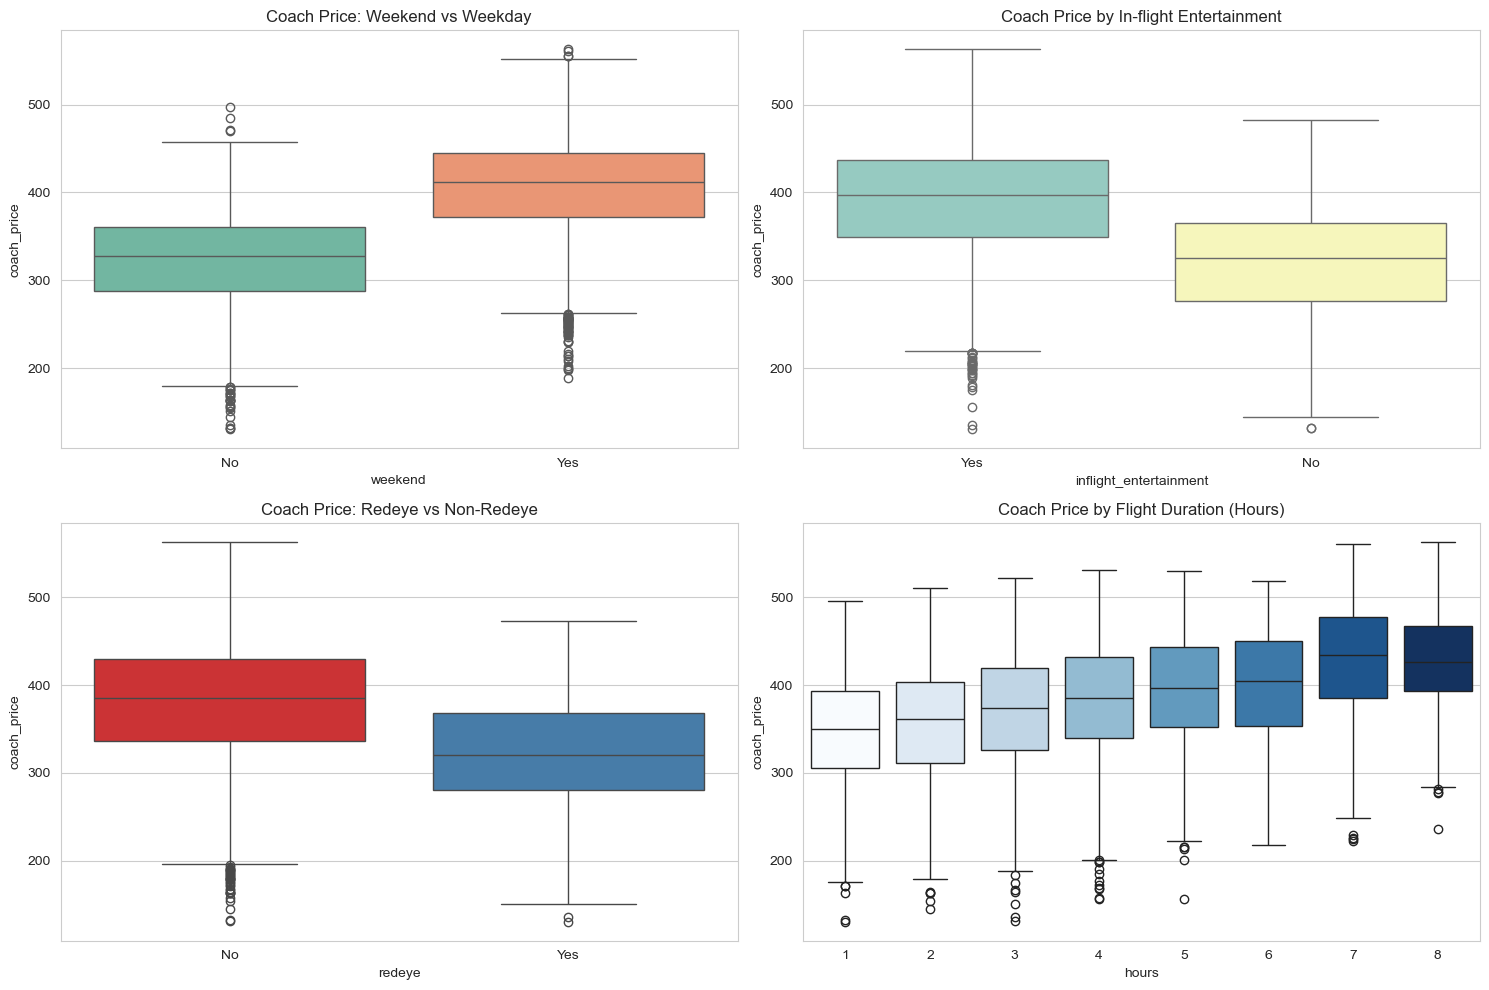

In [53]:
import pandas as pd
import numpy as np  # <-- Added this import
import matplotlib.pyplot as plt
import seaborn as sns

# Load data and sample
df = pd.read_csv('flight_data.csv')
np.random.seed(10063)
sample_df = df.sample(n=10063, random_state=10063).copy()

sns.set_style("whitegrid")

# Create multiple boxplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Coach Price by Weekend
sns.boxplot(x='weekend', y='coach_price', data=sample_df, ax=axes[0,0], palette='Set2', hue='weekend', legend=False)
axes[0,0].set_title('Coach Price: Weekend vs Weekday')

# 2. Coach Price by In-flight Entertainment
sns.boxplot(x='inflight_entertainment', y='coach_price', data=sample_df, ax=axes[0,1], palette='Set3', hue='inflight_entertainment', legend=False)
axes[0,1].set_title('Coach Price by In-flight Entertainment')

# 3. Coach Price by Redeye
sns.boxplot(x='redeye', y='coach_price', data=sample_df, ax=axes[1,0], palette='Set1', hue='redeye', legend=False)
axes[1,0].set_title('Coach Price: Redeye vs Non-Redeye')

# 4. Coach Price by Flight Hours
sns.boxplot(x='hours', y='coach_price', data=sample_df, ax=axes[1,1], palette='Blues', hue='hours', legend=False)
axes[1,1].set_title('Coach Price by Flight Duration (Hours)')

plt.tight_layout()
plt.show()

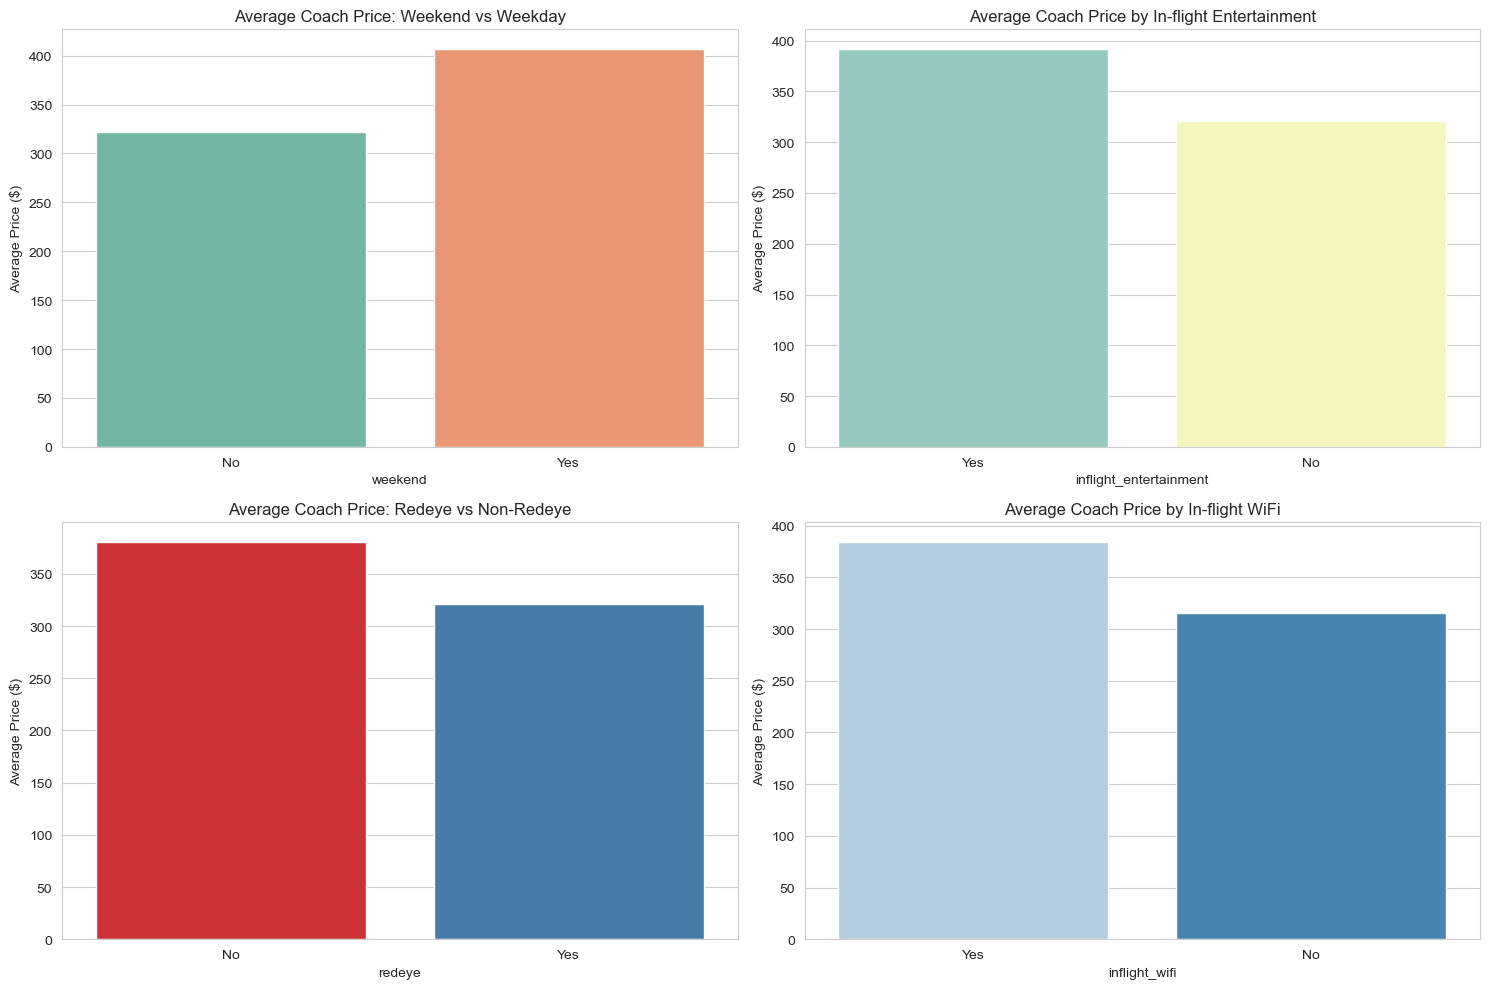

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data and sample
df = pd.read_csv('flight_data.csv')
np.random.seed(10063)
sample_df = df.sample(n=10063, random_state=10063).copy()

sns.set_style("whitegrid")

# Create Bar Charts
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Average Coach Price by Weekend
sns.barplot(x='weekend', y='coach_price', hue='weekend', data=sample_df, ax=axes[0,0], estimator='mean', errorbar=None, palette='Set2', legend=False)
axes[0,0].set_title('Average Coach Price: Weekend vs Weekday')
axes[0,0].set_ylabel('Average Price ($)')

# 2. Average Coach Price by In-flight Entertainment
sns.barplot(x='inflight_entertainment', y='coach_price', hue='inflight_entertainment', data=sample_df, ax=axes[0,1], estimator='mean', errorbar=None, palette='Set3', legend=False)
axes[0,1].set_title('Average Coach Price by In-flight Entertainment')
axes[0,1].set_ylabel('Average Price ($)')

# 3. Average Coach Price by Redeye
sns.barplot(x='redeye', y='coach_price', hue='redeye', data=sample_df, ax=axes[1,0], estimator='mean', errorbar=None, palette='Set1', legend=False)
axes[1,0].set_title('Average Coach Price: Redeye vs Non-Redeye')
axes[1,0].set_ylabel('Average Price ($)')

# 4. Average Coach Price by In-flight WiFi
sns.barplot(x='inflight_wifi', y='coach_price', hue='inflight_wifi', data=sample_df, ax=axes[1,1], estimator='mean', errorbar=None, palette='Blues', legend=False)
axes[1,1].set_title('Average Coach Price by In-flight WiFi')
axes[1,1].set_ylabel('Average Price ($)')

plt.tight_layout()
plt.show()

In [56]:
import pandas as pd
from scipy import stats

# Load data and sample
df = pd.read_csv('flight_data.csv')
np.random.seed(10063)
sample_df = df.sample(n=10063, random_state=10063).copy()

print("=== INDEPENDENT T-TESTS TO COMPARE GROUP MEANS ===\n")

# 1. Weekend vs Weekday
print("1. Weekend vs Weekday")
weekend = sample_df[sample_df['weekend'] == 'Yes']['coach_price']
weekday = sample_df[sample_df['weekend'] == 'No']['coach_price']

t1, p1 = stats.ttest_ind(weekend, weekday, equal_var=False)
print(f"T-statistic : {t1:.4f} | P-value : {p1:.10f}")
print(f"Weekend Mean : ${weekend.mean():.2f} | Weekday Mean : ${weekday.mean():.2f}\n")

# 2. Redeye vs Non-Redeye
print("2. Redeye vs Non-Redeye")
redeye_yes = sample_df[sample_df['redeye'] == 'Yes']['coach_price']
redeye_no  = sample_df[sample_df['redeye'] == 'No']['coach_price']

t2, p2 = stats.ttest_ind(redeye_yes, redeye_no, equal_var=False)
print(f"T-statistic : {t2:.4f} | P-value : {p2:.10f}")
print(f"Redeye Mean : ${redeye_yes.mean():.2f} | Non-Redeye Mean : ${redeye_no.mean():.2f}\n")

# 3. In-flight Entertainment Yes vs No
print("3. In-flight Entertainment")
ent_yes = sample_df[sample_df['inflight_entertainment'] == 'Yes']['coach_price']
ent_no  = sample_df[sample_df['inflight_entertainment'] == 'No']['coach_price']

t3, p3 = stats.ttest_ind(ent_yes, ent_no, equal_var=False)
print(f"T-statistic : {t3:.4f} | P-value : {p3:.10f}")
print(f"With Entertainment : ${ent_yes.mean():.2f} | Without : ${ent_no.mean():.2f}\n")

# 4. In-flight WiFi Yes vs No
print("4. In-flight WiFi")
wifi_yes = sample_df[sample_df['inflight_wifi'] == 'Yes']['coach_price']
wifi_no  = sample_df[sample_df['inflight_wifi'] == 'No']['coach_price']

t4, p4 = stats.ttest_ind(wifi_yes, wifi_no, equal_var=False)
print(f"T-statistic : {t4:.4f} | P-value : {p4:.10f}")
print(f"With WiFi : ${wifi_yes.mean():.2f} | Without : ${wifi_no.mean():.2f}")

=== INDEPENDENT T-TESTS TO COMPARE GROUP MEANS ===

1. Weekend vs Weekday
T-statistic : 74.2530 | P-value : 0.0000000000
Weekend Mean : $406.54 | Weekday Mean : $322.32

2. Redeye vs Non-Redeye
T-statistic : -20.5766 | P-value : 0.0000000000
Redeye Mean : $321.23 | Non-Redeye Mean : $380.72

3. In-flight Entertainment
T-statistic : 46.1579 | P-value : 0.0000000000
With Entertainment : $391.52 | Without : $320.49

4. In-flight WiFi
T-statistic : 31.8131 | P-value : 0.0000000000
With WiFi : $384.37 | Without : $315.14


In [57]:
import pandas as pd
import numpy as np
from scipy import stats

# Load data and sample
df = pd.read_csv('flight_data.csv')
np.random.seed(10063)
sample_df = df.sample(n=10063, random_state=10063).copy()

print("=== Z-TEST: REDEYE vs NON-REDEYE FLIGHTS ===\n")

# Groups
redeye_yes = sample_df[sample_df['redeye'] == 'Yes']['coach_price']
redeye_no  = sample_df[sample_df['redeye'] == 'No']['coach_price']

# Z-Test Calculation
mean1 = redeye_yes.mean()
mean2 = redeye_no.mean()
std1 = redeye_yes.std()
std2 = redeye_no.std()
n1 = len(redeye_yes)
n2 = len(redeye_no)

z_stat = (mean1 - mean2) / np.sqrt((std1**2 / n1) + (std2**2 / n2))
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print(f"Z-Statistic     : {z_stat:.4f}")
print(f"P-Value         : {p_value:.10f}")
print(f"Redeye Mean     : ${mean1:.2f}")
print(f"Non-Redeye Mean : ${mean2:.2f}")
print(f"Sample Size (Redeye)    : {n1}")
print(f"Sample Size (Non-Redeye): {n2}")

=== Z-TEST: REDEYE vs NON-REDEYE FLIGHTS ===

Z-Statistic     : -20.5766
P-Value         : 0.0000000000
Redeye Mean     : $321.23
Non-Redeye Mean : $380.72
Sample Size (Redeye)    : 506
Sample Size (Non-Redeye): 9557


In [58]:
import pandas as pd
from scipy.stats import chi2_contingency

# Load data and sample
df = pd.read_csv('flight_data.csv')
np.random.seed(10063)
sample_df = df.sample(n=10063, random_state=10063).copy()

print("=== CHI-SQUARE TESTS OF INDEPENDENCE ===\n")

# 1. In-flight Entertainment vs Weekend
print("1. In-flight Entertainment vs Weekend")
cont1 = pd.crosstab(sample_df['inflight_entertainment'], sample_df['weekend'])
chi2, p, dof, expected = chi2_contingency(cont1)
print(f"Chi2 Statistic : {chi2:.4f}")
print(f"P-value        : {p:.10f}")
print(f"Degrees of Freedom: {dof}\n")

# 2. In-flight WiFi vs Weekend
print("2. In-flight WiFi vs Weekend")
cont2 = pd.crosstab(sample_df['inflight_wifi'], sample_df['weekend'])
chi2, p, dof, expected = chi2_contingency(cont2)
print(f"Chi2 Statistic : {chi2:.4f}")
print(f"P-value        : {p:.10f}")
print(f"Degrees of Freedom: {dof}\n")

# 3. Redeye vs Weekend
print("3. Redeye vs Weekend")
cont3 = pd.crosstab(sample_df['redeye'], sample_df['weekend'])
chi2, p, dof, expected = chi2_contingency(cont3)
print(f"Chi2 Statistic : {chi2:.4f}")
print(f"P-value        : {p:.10f}")
print(f"Degrees of Freedom: {dof}\n")

# 4. In-flight Meal vs Weekend
print("4. In-flight Meal vs Weekend")
cont4 = pd.crosstab(sample_df['inflight_meal'], sample_df['weekend'])
chi2, p, dof, expected = chi2_contingency(cont4)
print(f"Chi2 Statistic : {chi2:.4f}")
print(f"P-value        : {p:.10f}")

=== CHI-SQUARE TESTS OF INDEPENDENCE ===

1. In-flight Entertainment vs Weekend
Chi2 Statistic : 2.7028
P-value        : 0.1001746840
Degrees of Freedom: 1

2. In-flight WiFi vs Weekend
Chi2 Statistic : 0.0461
P-value        : 0.8299171805
Degrees of Freedom: 1

3. Redeye vs Weekend
Chi2 Statistic : 2.2572
P-value        : 0.1329981133
Degrees of Freedom: 1

4. In-flight Meal vs Weekend
Chi2 Statistic : 0.8396
P-value        : 0.3595119067


In [59]:
import pandas as pd
from scipy import stats

# Load data and sample
df = pd.read_csv('flight_data.csv')
np.random.seed(10063)
sample_df = df.sample(n=10063, random_state=10063).copy()

# Analysis
weekend = sample_df[sample_df['weekend'] == 'Yes']['coach_price']
weekday = sample_df[sample_df['weekend'] == 'No']['coach_price']

print("=== PRICE DIFFERENCES BETWEEN WEEKEND AND WEEKDAY FLIGHTS ===\n")
print(f"Number of Weekend Flights   : {len(weekend)}")
print(f"Number of Weekday Flights   : {len(weekday)}")
print(f"Weekend Mean Price          : ${weekend.mean():.2f}")
print(f"Weekday Mean Price          : ${weekday.mean():.2f}")
print(f"Absolute Difference         : ${weekend.mean() - weekday.mean():.2f}")
print(f"Percentage Increase         : {((weekend.mean() - weekday.mean()) / weekday.mean() * 100):.2f}%")

# Statistical Significance
t_stat, p_value = stats.ttest_ind(weekend, weekday, equal_var=False)
print(f"\nt-statistic                 : {t_stat:.4f}")
print(f"p-value                     : {p_value:.10f}")

=== PRICE DIFFERENCES BETWEEN WEEKEND AND WEEKDAY FLIGHTS ===

Number of Weekend Flights   : 6620
Number of Weekday Flights   : 3443
Weekend Mean Price          : $406.54
Weekday Mean Price          : $322.32
Absolute Difference         : $84.22
Percentage Increase         : 26.13%

t-statistic                 : 74.2530
p-value                     : 0.0000000000


In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load data and sample
df = pd.read_csv('flight_data.csv')
np.random.seed(10063)
sample_df = df.sample(n=10063, random_state=10063).copy()

# Numeric Variables
numeric_cols = ['miles', 'passengers', 'delay', 'hours', 
                'coach_price', 'firstclass_price']

# Correlation Matrix
corr_matrix = sample_df[numeric_cols].corr()

print("=== CORRELATION MATRIX ===\n")
print(corr_matrix.round(4))

print("\n=== Correlation with Coach Price (Sorted) ===")
print(corr_matrix['coach_price'].sort_values(ascending=False).round(4))

=== CORRELATION MATRIX ===

                   miles  passengers   delay   hours  coach_price  \
miles             1.0000     -0.0059  0.0149  0.9858       0.3408   
passengers       -0.0059      1.0000  0.0025 -0.0071       0.1667   
delay             0.0149      0.0025  1.0000  0.0192       0.0129   
hours             0.9858     -0.0071  0.0192  1.0000       0.3344   
coach_price       0.3408      0.1667  0.0129  0.3344       1.0000   
firstclass_price  0.2887      0.0106  0.0117  0.2863       0.7547   

                  firstclass_price  
miles                       0.2887  
passengers                  0.0106  
delay                       0.0117  
hours                       0.2863  
coach_price                 0.7547  
firstclass_price            1.0000  

=== Correlation with Coach Price (Sorted) ===
coach_price         1.0000
firstclass_price    0.7547
miles               0.3408
hours               0.3344
passengers          0.1667
delay               0.0129
Name: coach_price, d

In [62]:
import pandas as pd
import statsmodels.api as sm

# Load data and sample
df = pd.read_csv('flight_data.csv')
np.random.seed(10063)
sample_df = df.sample(n=10063, random_state=10063).copy()

# Define features and target
X = sample_df[['miles', 'hours', 'passengers', 'delay']]
X = sm.add_constant(X)        # Add intercept
y = sample_df['coach_price']

# Fit the model
model = sm.OLS(y, X).fit()

# Print summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            coach_price   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.144
Method:                 Least Squares   F-statistic:                     425.6
Date:                Mon, 18 May 2026   Prob (F-statistic):               0.00
Time:                        01:54:06   Log-Likelihood:                -55838.
No. Observations:               10063   AIC:                         1.117e+05
Df Residuals:                   10058   BIC:                         1.117e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        145.7542     10.113     14.413      0.0

In [64]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Load data and sample
df = pd.read_csv('flight_data.csv')
np.random.seed(10063)
sample_df = df.sample(n=10063, random_state=10063).copy()

# Data Preparation: Encode target and categorical variables to (1/0)
sample_df['redeye_num'] = sample_df['redeye'].map({'Yes': 1, 'No': 0})
sample_df['weekend_num'] = sample_df['weekend'].map({'Yes': 1, 'No': 0})

# Fit Logistic Regression Model using Formula API
formula = 'redeye_num ~ miles + hours + passengers + delay + weekend_num'
model = smf.logit(formula, data=sample_df).fit()

# Print summary
print(model.summary())

# Calculate Odds Ratios and 95% Confidence Intervals
print("\n" + "="*20 + " ODDS RATIOS & 95% CI " + "="*20)
params = model.params
conf_int = model.conf_int()

results_df = pd.concat([params, conf_int], axis=1)
results_df.columns = ['Odds Ratio', '2.5%', '97.5%']
results_df = np.exp(results_df)

print(results_df)

Optimization terminated successfully.
         Current function value: 0.000753
         Iterations 19
                           Logit Regression Results                           
Dep. Variable:             redeye_num   No. Observations:                10063
Model:                          Logit   Df Residuals:                    10057
Method:                           MLE   Df Model:                            5
Date:                Mon, 18 May 2026   Pseudo R-squ.:                  0.9962
Time:                        02:07:53   Log-Likelihood:                -7.5730
converged:                       True   LL-Null:                       -2006.0
Covariance Type:            nonrobust   LLR p-value:                     0.000
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     244.1917     84.365      2.894      0.004      78.838     409.545
miles          -0.0010   